In [1]:
from lappy import *
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

In [16]:
dom = geometry.right_trapezoid(1.55,2-1.55)
n1, n2 = 5,15
basis = FourierBesselBasis.from_domain(dom, [0, 0, n1, n2])

# build bdry and int pts
n_bdry = 4*len(basis)
seg_mask = np.array([True,True,False,True])
pts_per_seg = np.zeros(4, dtype=int)
pts_per_seg[seg_mask] = np.round(n_bdry*dom.seg_lens[seg_mask]/dom.seg_lens[seg_mask].sum()).astype(int)
bdry_pts = dom.bdry_pts(pts_per_seg)
int_pts = dom.int_pts()
basis = NormalizedBasis(basis, (bdry_pts, int_pts))

# solver and evp
solver = MPSEigensolver(basis, bdry_pts, int_pts, ltol=1e-15, ttol=1e-1)
lam_fk = bounds.faber_krahn(dom)
solver.rtol = solver.adapt_rtol(lam_fk,1.25*lam_fk)
eigprob = Eigenproblem(dom, solver)

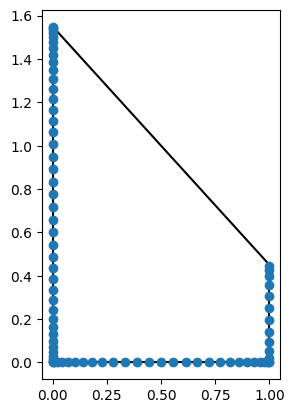

In [17]:
fig,ax = plt.subplots()
dom.plot(ax=ax)
plt.plot(bdry_pts.x, bdry_pts.y, 'o')
ax.set_aspect('equal')
plt.show()

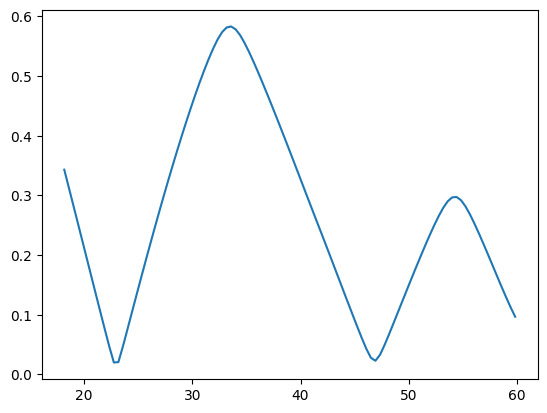

In [18]:
solver.plot_tensions(lam_fk, asymp.weyl_est(2, trap), 100, rtol=1e-5)
plt.show()